# Edge prediction training

Train a graph attention network link predictor, evaluate held-out edges, and compare training and validation metrics across epochs.

## Locate the project and configure imports

Find the repository root from the notebook working directory, switch to it, and add the prediction package to Python’s import path.

In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents)
     if (path / "prediction" / "src" / "train.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate EmbedKG_EGCN. Open this notebook from the repository "
        "or one of its subdirectories."
    )

os.chdir(PROJECT_ROOT)
PREDICTION_ROOT = PROJECT_ROOT / "prediction"
if str(PREDICTION_ROOT) not in sys.path:
    sys.path.insert(0, str(PREDICTION_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/EmbedKG_EGCN


## Imports

Load the graph utilities, model classes, metric functions, and libraries used by the training and plotting cells.

In [2]:
import itertools
import json
import os
from argparse import Namespace

import dgl
import numpy as np
import scipy.sparse as sp
import torch

from src.data_loader import load_graph_data
from src.models import FocalLoss, GATModel, MLPPredictor
from src.utils import (
    compute_accuracy,
    compute_accuracy_with_symmetrical_confidence,
    compute_auc,
    compute_auc_with_symmetrical_confidence,
    compute_f1,
    compute_f1_with_symmetrical_confidence,
    compute_focalloss,
    compute_focalloss_with_symmetrical_confidence,
    compute_hits_k,
    compute_map,
    compute_map_with_symmetrical_confidence,
    compute_precision,
    compute_precision_with_symmetrical_confidence,
    compute_recall,
    compute_recall_with_symmetrical_confidence,
)


## Plotting metrics

Define a helper that plots training and validation F1, focal loss, AUC, mAP, recall, accuracy, and precision by epoch. It saves one PNG per metric under the results directory.

In [3]:
import os
from matplotlib import pyplot as plt


def plot_scores(epochs, train_f1_scores, val_f1_scores, train_focal_loss_scores, val_focal_loss_scores, train_auc_scores, val_auc_scores,
                train_map_scores, val_map_scores, train_recall_scores, val_recall_scores,
                train_acc_scores, val_acc_scores, train_precision_scores, val_precision_scores,
                output_path, args):
    # Ensure the output directory exists
    os.makedirs(output_path, exist_ok=True)

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_f1_scores, label='Training F1 Score')
    plt.plot(epochs, val_f1_scores, label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('Training and Validation F1 Scores over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'f1_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_focal_loss_scores, label='Training FocalLoss Score')
    plt.plot(epochs, val_focal_loss_scores, label='Validation FocalLoss Score')
    plt.xlabel('Epochs')
    plt.ylabel('FocalLoss Score')
    plt.title('Training and Validation FocalLoss Scores over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'loss_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_auc_scores, label='Training AUC')
    plt.plot(epochs, val_auc_scores, label='Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.title('Training and Validation AUC over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'auc_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_map_scores, label='Training mAP')
    plt.plot(epochs, val_map_scores, label='Validation mAP')
    plt.xlabel('Epochs')
    plt.ylabel('mAP')
    plt.title('Training and Validation mAP over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'mAP_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_recall_scores, label='Training Recall')
    plt.plot(epochs, val_recall_scores, label='Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Training and Validation Recall over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'recall_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    ##plt.figure(figsize=(15, 5))

    ##plt.subplot(1, 2, 1)
    plt.figure()
    plt.plot(epochs, train_acc_scores, label='Training Accuracy')
    plt.plot(epochs, val_acc_scores, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'acc_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    plt.figure()
    plt.plot(epochs, train_precision_scores, label='Training Precision')
    plt.plot(epochs, val_precision_scores, label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Training and Validation Precision over Epochs')
    plt.legend()
    ##plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.savefig(os.path.join(output_path, f'precision_head{args.num_heads}_dim{args.out_feats}_lay{args.num_layers}_epo{args.epochs}.png'))

    plt.show()


## Training function

Split positive and negative edges into training, validation, and test sets; train the GAT and MLP predictor; record epoch histories; evaluate test metrics; and save the model and test results.

In [4]:
def train_and_evaluate(args, G_dgl, node_features):
    u, v = G_dgl.edges()
    eids = np.arange(G_dgl.number_of_edges())
    eids = np.random.permutation(eids)
    test_size = int(len(eids) * 0.1)
    val_size = int(len(eids) * 0.1)
    train_size = G_dgl.number_of_edges() - test_size - val_size

    test_pos_u, test_pos_v = u[eids[:test_size]], v[eids[:test_size]]
    val_pos_u, val_pos_v = u[eids[test_size:test_size + val_size]], v[eids[test_size:test_size + val_size]]
    train_pos_u, train_pos_v = u[eids[test_size + val_size:]], v[eids[test_size + val_size:]]

    ##adj = sp.coo_matrix((np.ones(len(u)), (u.numpy(), v.numpy())))
    
    adj = sp.coo_matrix((np.ones(len(u)), (u.numpy(), v.numpy())), shape=(G_dgl.number_of_nodes(), G_dgl.number_of_nodes()))
    adj_neg = 1 - adj.todense() - np.eye(G_dgl.number_of_nodes())
    neg_u, neg_v = np.where(adj_neg != 0)

    neg_eids = np.random.choice(len(neg_u), G_dgl.number_of_edges())
    test_neg_u, test_neg_v = neg_u[neg_eids[:test_size]], neg_v[neg_eids[:test_size]]
    val_neg_u, val_neg_v = neg_u[neg_eids[test_size:test_size + val_size]], neg_v[neg_eids[test_size:test_size + val_size]]
    train_neg_u, train_neg_v = neg_u[neg_eids[test_size + val_size:]], neg_v[neg_eids[test_size + val_size:]]

    train_g = dgl.remove_edges(G_dgl, eids[:test_size + val_size])

    def create_graph(u, v, num_nodes):
        assert len(u) == len(v), "Source and destination nodes must have the same length"
        return dgl.graph((u, v), num_nodes=num_nodes)

    train_pos_g = create_graph(train_pos_u, train_pos_v, G_dgl.number_of_nodes())
    train_neg_g = create_graph(train_neg_u, train_neg_v, G_dgl.number_of_nodes())
    val_pos_g = create_graph(val_pos_u, val_pos_v, G_dgl.number_of_nodes())
    val_neg_g = create_graph(val_neg_u, val_neg_v, G_dgl.number_of_nodes())
    test_pos_g = create_graph(test_pos_u, test_pos_v, G_dgl.number_of_nodes())
    test_neg_g = create_graph(test_neg_u, test_neg_v, G_dgl.number_of_nodes())

    model = GATModel(
        node_features.shape[1], 
        out_feats=args.out_feats, 
        num_layers=args.num_layers, 
        num_heads=args.num_heads, 
        feat_drop=args.feat_drop, 
        attn_drop=args.attn_drop, 
        do_train=True
    )

    pred = MLPPredictor(args.input_size, args.hidden_size)
    criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean')

    optimizer = torch.optim.Adam(itertools.chain(model.parameters(), pred.parameters()), lr=args.lr)

    # Initialize StepLR scheduler
    ##scheduler = StepLR(optimizer, step_size=200, gamma=0.1)  # Adjust step_size and gamma as needed
    scheduler = ExponentialLR(optimizer, gamma=0.9) 

    output_path = './prediction/results/'
    os.makedirs(output_path, exist_ok=True)
    
    train_f1_scores = []
    val_f1_scores = []
    train_focal_loss_scores = []
    val_focal_loss_scores = []
    train_auc_scores = []
    val_auc_scores = []
    train_map_scores = []
    val_map_scores = []
    train_recall_scores = []
    val_recall_scores = []
    train_acc_scores = []
    val_acc_scores = []
    train_precision_scores = []
    val_precision_scores = []

    ##for epoch in range(num_epochs):
    for e in range(args.epochs):
        model.train()
        h = model(train_g, train_g.ndata['feat'])
        pos_score = pred(train_pos_g, h)
        neg_score = pred(train_neg_g, h)

        pos_labels = torch.ones_like(pos_score)
        neg_labels = torch.zeros_like(neg_score)

        all_scores = torch.cat([pos_score, neg_score])
        all_labels = torch.cat([pos_labels, neg_labels])

        loss = criterion(all_scores, all_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
     
        # Update the learning rate
        '''        
        scheduler.step()
 
        # Print the current learning rate
        if e % 200 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch {e}: Learning Rate = {current_lr:.6f}') 
        
        '''    
               
        if e % 5 == 0:
            print(f'In epoch {e}, loss: {loss.item()}')


        with torch.no_grad():
            h_train = model(train_g, train_g.ndata['feat'])
            train_pos_score = pred(train_pos_g, h_train)
            train_neg_score = pred(train_neg_g, h_train)
            train_f1 = compute_f1(train_pos_score, train_neg_score)
            train_f1_scores.append(train_f1.item())
            train_focal_loss= compute_focalloss(train_pos_score, train_neg_score)
            train_focal_loss_scores.append(train_focal_loss)
            train_auc = compute_auc(train_pos_score, train_neg_score)
            train_auc_scores.append(train_auc.item())
            train_map = compute_map(train_pos_score, train_neg_score)
            train_map_scores.append(train_map.item())
            train_recall = compute_recall(train_pos_score, train_neg_score)
            train_recall_scores.append(train_recall.item())
            train_acc = compute_accuracy(train_pos_score, train_neg_score)
            train_acc_scores.append(train_acc)
            train_precision = compute_precision(train_pos_score, train_neg_score)
            train_precision_scores.append(train_precision)

            h_val = model(train_g, train_g.ndata['feat'])
            val_pos_score = pred(val_pos_g, h_val)
            val_neg_score = pred(val_neg_g, h_val)
            val_f1 = compute_f1(val_pos_score, val_neg_score)
            val_f1_scores.append(val_f1.item())
            val_focal_loss= compute_focalloss(val_pos_score, val_neg_score)
            val_focal_loss_scores.append(val_focal_loss)
            val_auc = compute_auc(val_pos_score, val_neg_score)
            val_auc_scores.append(val_auc.item())
            val_map = compute_map(val_pos_score, val_neg_score)
            val_map_scores.append(val_map.item())
            val_recall = compute_recall(val_pos_score, val_neg_score)
            val_recall_scores.append(val_recall.item())
            val_acc = compute_accuracy(val_pos_score, val_neg_score)
            val_acc_scores.append(val_acc)
            val_precision = compute_precision(val_pos_score, val_neg_score)
            val_precision_scores.append(val_precision)

    epochs = range(args.epochs)
    ##epochs = list(map(int, epochs))

    
    with torch.no_grad():
        model.eval()
        h_test = model(G_dgl, G_dgl.ndata['feat'])
        test_pos_score = pred(test_pos_g, h_test)
        test_neg_score = pred(test_neg_g, h_test)
        test_auc, test_auc_err = compute_auc_with_symmetrical_confidence(test_pos_score, test_neg_score)
        test_f1, test_f1_err = compute_f1_with_symmetrical_confidence(test_pos_score, test_neg_score)
        test_focal_loss, test_focal_loss_err = compute_focalloss_with_symmetrical_confidence(test_pos_score, test_neg_score)#train_focal_loss, train_focal_loss_err
        test_precision, test_precision_err = compute_precision_with_symmetrical_confidence(test_pos_score, test_neg_score)
        test_recall, test_recall_err = compute_recall_with_symmetrical_confidence(test_pos_score, test_neg_score)
        test_hits_k = compute_hits_k(test_pos_score, test_neg_score, k=10)
        test_map, test_map_err = compute_map_with_symmetrical_confidence(test_pos_score, test_neg_score)
        test_accuracy, test_accuracy_err = compute_accuracy_with_symmetrical_confidence(test_pos_score, test_neg_score)

        print(f'Test AUC: {test_auc:.4f} ± {test_auc_err:.4f} | Test F1: {test_f1:.4f} ± {test_f1_err:.4f} | Test FocalLoss: {test_focal_loss:.4f} ± {test_focal_loss_err:.4f} |Test Accuracy: {test_accuracy:.4f} ± {test_accuracy_err:.4f} | Test Precision: {test_precision:.4f} ± {test_precision_err:.4f} | Test Recall: {test_recall:.4f} ± {test_recall_err:.4f} | Test mAP: {test_map:.4f} ± {test_map_err:.4f}')

    model_path = './prediction/results/pred_model.pth'
    torch.save(pred.state_dict(), model_path)
    


    test_auc = test_auc.item()
    test_f1 = test_f1.item()
    ##test_focal_loss = test_focal_loss.item()
    test_precision = test_precision.item()
    test_recall = test_recall.item()
    test_hits_k = test_hits_k.item()
    test_map = test_map.item()
    ##test_accuracy = test_accuracy.item()

    test_auc_err = test_auc_err.item()
    test_f1_err = test_f1_err.item()
    ##test_focal_loss_err = test_focal_loss_err.item()
    test_precision_err = test_precision_err.item()
    test_recall_err = test_recall_err.item()
    test_map_err = test_map_err.item()

    output = {
        'Test AUC': f'{test_auc:.4f} ± {test_auc_err:.4f}',
        'Test F1 Score': f'{test_f1:.4f} ± {test_f1_err:.4f}',
        'Test FocalLoss Score': f'{test_focal_loss:.4f} ± {test_focal_loss_err:.4f}',
        'Test Precision': f'{test_precision:.4f} ± {test_precision_err:.4f}',
        'Test Recall': f'{test_recall:.4f} ± {test_recall_err:.4f}',
        'Test Hit': f'{test_hits_k:.4f}',  # Assuming no confidence interval for Hits@K
        'Test mAP': f'{test_map:.4f} ± {test_map_err:.4f}',
        'Test Accuracy': f'{test_accuracy:.4f} ± {test_accuracy_err:.4f}'
    }

    filename_ = f'test_head{args.num_heads}_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.json'
    
    with open(os.path.join(output_path, filename_), 'w') as f:
        json.dump(output, f)

    filename = f'test_head{args.num_heads}_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.json'
    
    test_results = {
        'Learning Rate': args.lr,
        'Epochs': args.epochs,
        'Input Features': args.input_size,
        'Output Features': args.out_feats,
        'Test AUC': f'{test_auc:.4f} ± {test_auc_err:.4f}',
        'Test F1 Score': f'{test_f1:.4f} ± {test_f1_err:.4f}',
        'Test FocalLoss Score': f'{test_focal_loss:.4f} ± {test_focal_loss_err:.4f}',
        'Test Precision': f'{test_precision:.4f} ± {test_precision_err:.4f}',
        'Test Recall': f'{test_recall:.4f} ± {test_recall_err:.4f}',
        'Test Hit': f'{test_hits_k:.4f}',
        'Test mAP': f'{test_map:.4f} ± {test_map_err:.4f}',
        'Test Accuracy': f'{test_accuracy:.4f} ± {test_accuracy_err:.4f}'
    }

    with open(os.path.join(output_path, filename), 'w') as f:
        json.dump(test_results, f)

    return {
        "epochs": epochs,
        "train_f1_scores": train_f1_scores,
        "val_f1_scores": val_f1_scores,
        "train_focal_loss_scores": train_focal_loss_scores,
        "val_focal_loss_scores": val_focal_loss_scores,
        "train_auc_scores": train_auc_scores,
        "val_auc_scores": val_auc_scores,
        "train_map_scores": train_map_scores,
        "val_map_scores": val_map_scores,
        "train_recall_scores": train_recall_scores,
        "val_recall_scores": val_recall_scores,
        "train_acc_scores": train_acc_scores,
        "val_acc_scores": val_acc_scores,
        "train_precision_scores": train_precision_scores,
        "val_precision_scores": val_precision_scores,
        "output_path": output_path,
    }

## Training parameters

Set the model dimensions, attention heads, number of layers, epochs, learning rate, predictor size, and dropout rates. Adjust these values before training.

In [5]:
args = Namespace(
    in_feats=128,
    out_feats=128,
    num_heads=1,
    num_layers=2,
    epochs=20,
    lr=0.01,
    input_size=2,
    hidden_size=16,
    feat_drop=0.0,
    attn_drop=0.0,
)
args


Namespace(in_feats=128, out_feats=128, num_heads=1, num_layers=2, epochs=20, lr=0.01, input_size=2, hidden_size=16, feat_drop=0.0, attn_drop=0.0)

## Load graph data

Set `GRAPH_JSON` to the graph embedding JSON file, then load it as a DGL graph with node features.

In [6]:
# This is the same input path used by prediction/main.py. Change it if your JSON is elsewhere.
GRAPH_JSON = PROJECT_ROOT / "embedding" / "data" / "merged_gene_embeddings.json"
if not GRAPH_JSON.is_file():
    raise FileNotFoundError(
        f"Graph JSON not found: {GRAPH_JSON}. Update GRAPH_JSON to the location of your data."
    )

G_dgl, node_features = load_graph_data(str(GRAPH_JSON))
print(f"Loaded graph with {G_dgl.number_of_nodes()} nodes and {G_dgl.number_of_edges()} edges")


Loaded graph with 7528 nodes and 430533 edges


## Train and evaluate

Run the configured training loop. The function returns the epoch-by-epoch metric histories in `training_results` for the plotting cell below.

In [8]:
from torch.optim.lr_scheduler import StepLR,ExponentialLR

training_results = train_and_evaluate(args, G_dgl, node_features)


In epoch 0, loss: 0.04459957405924797
In epoch 5, loss: 0.040231164544820786
In epoch 10, loss: 0.03853413835167885
In epoch 15, loss: 0.037768203765153885
Test AUC: 0.7464 ± 0.0033 | Test F1: 0.2162 ± 0.0047 | Test FocalLoss: 0.1482 ± 0.0007 |Test Accuracy: 0.5484 ± 0.0017 | Test Precision: 0.8183 ± 0.0088 | Test Recall: 0.1245 ± 0.0031 | Test mAP: 0.7169 ± 0.0039


## Plot training metrics

Plot training and validation histories returned by the previous cell. This creates seven figures and saves them in `prediction/results/`. Re-run this cell after changing the parameters and rerunning training.

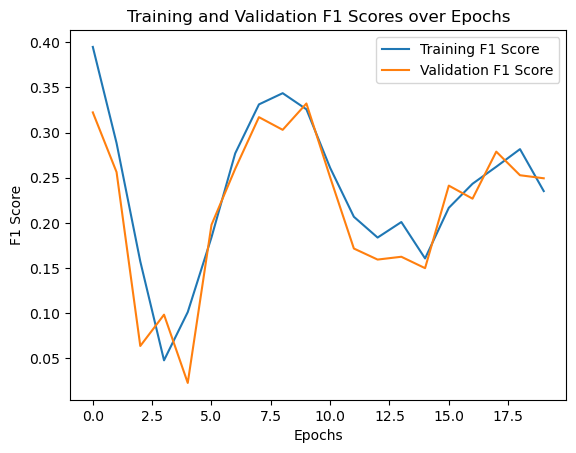

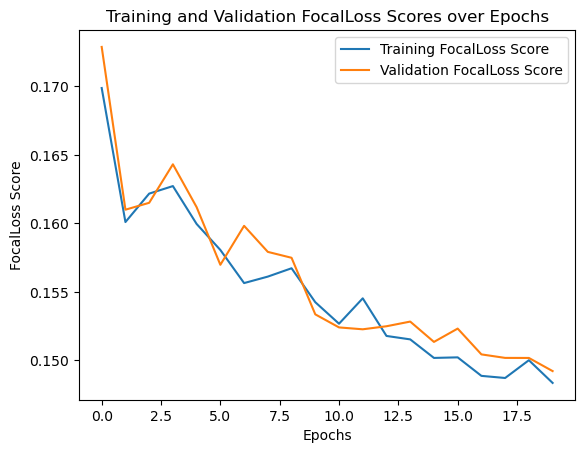

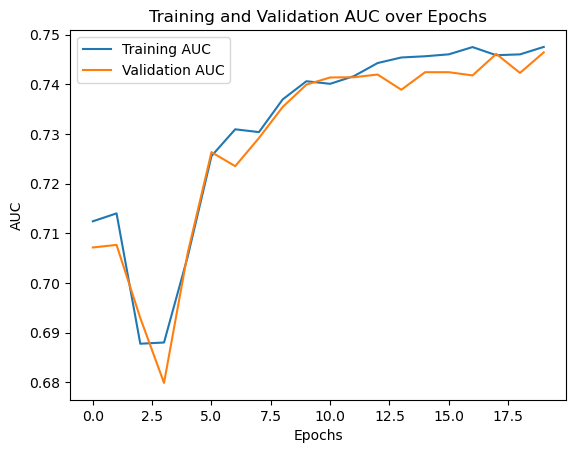

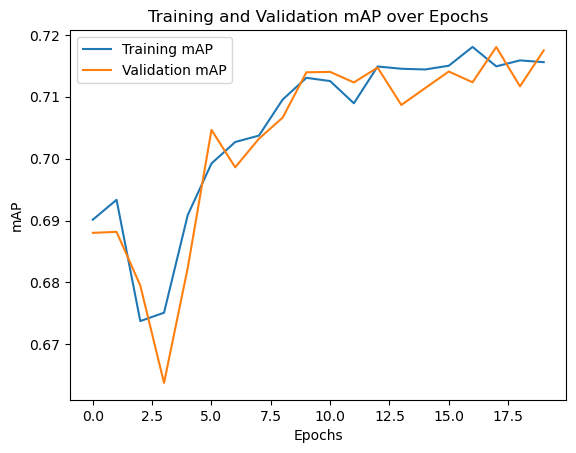

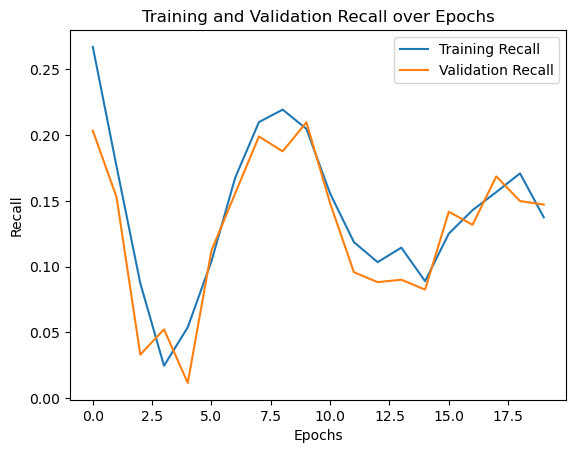

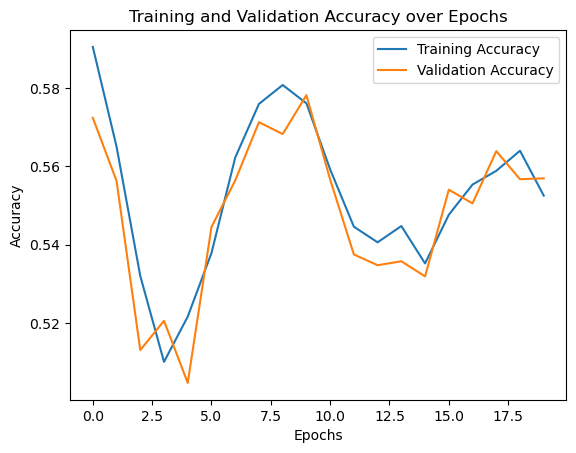

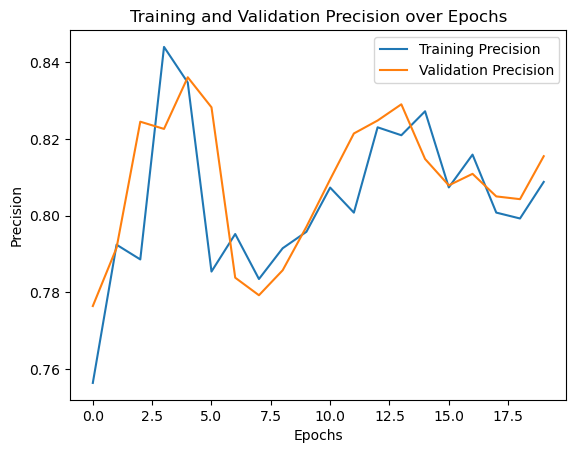

In [9]:
plot_scores(
    epochs=training_results["epochs"],
    train_f1_scores=training_results["train_f1_scores"],
    val_f1_scores=training_results["val_f1_scores"],
    train_focal_loss_scores=training_results["train_focal_loss_scores"],
    val_focal_loss_scores=training_results["val_focal_loss_scores"],
    train_auc_scores=training_results["train_auc_scores"],
    val_auc_scores=training_results["val_auc_scores"],
    train_map_scores=training_results["train_map_scores"],
    val_map_scores=training_results["val_map_scores"],
    train_recall_scores=training_results["train_recall_scores"],
    val_recall_scores=training_results["val_recall_scores"],
    train_acc_scores=training_results["train_acc_scores"],
    val_acc_scores=training_results["val_acc_scores"],
    train_precision_scores=training_results["train_precision_scores"],
    val_precision_scores=training_results["val_precision_scores"],
    output_path=training_results["output_path"],
    args=args,
)
